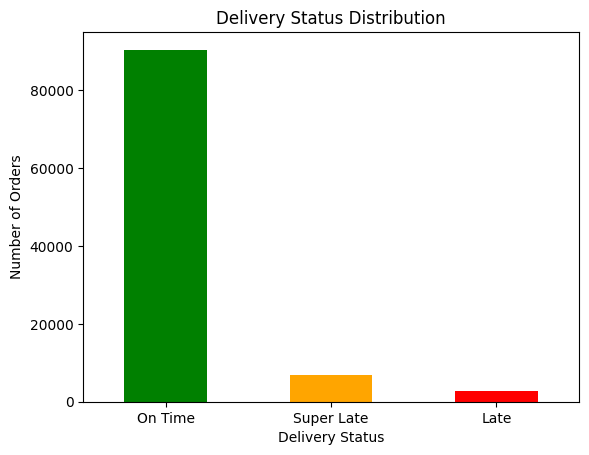

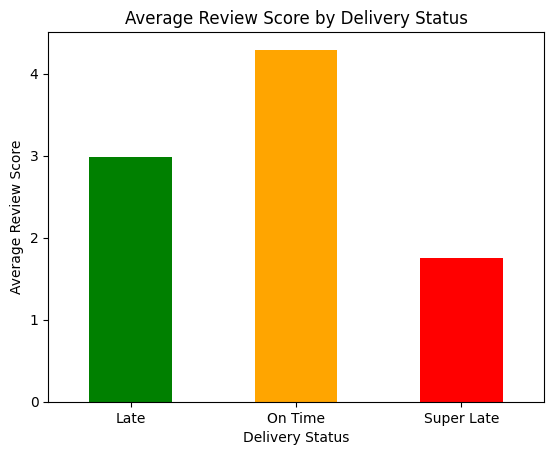

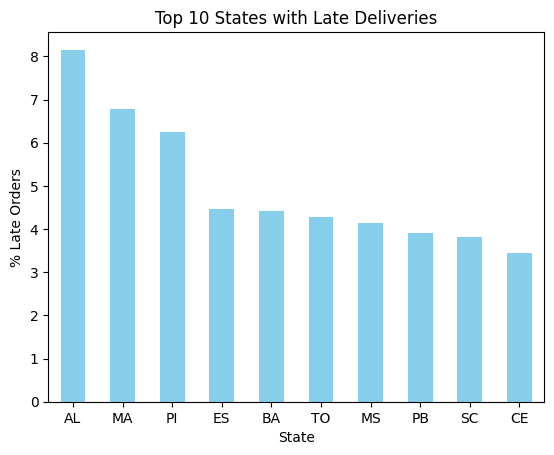

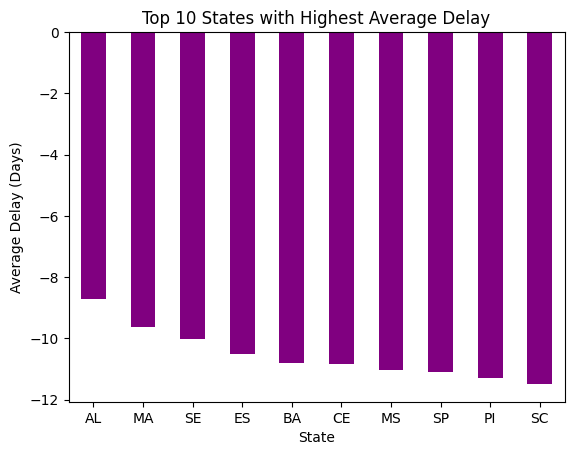

Analysis Completed Successfully


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("cleaned_master_data.csv")

# Convert dates
df["order_delivered_customer_date"] = pd.to_datetime(
    df["order_delivered_customer_date"]
)

df["order_estimated_delivery_date"] = pd.to_datetime(
    df["order_estimated_delivery_date"]
)

# Create delay column
df["delay_days"] = (
    df["order_delivered_customer_date"]
    - df["order_estimated_delivery_date"]
).dt.days

# Create delivery status
df["delivery_status"] = df["delay_days"].apply(
    lambda x: "On Time"
    if x <= 0
    else ("Late" if x <= 5 else "Super Late")
)

# -------------------------------
# CHART 1
# Delivery Status Distribution
# -------------------------------

df["delivery_status"].value_counts().plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

# -------------------------------
# CHART 2
# Review Score by Delivery Status
# -------------------------------

df.groupby("delivery_status")["review_score"].mean().plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.show()

# -------------------------------
# CHART 3
# Late Deliveries by State
# -------------------------------

state_late = df.groupby("customer_state")["delivery_status"].apply(
    lambda x: (x == "Late").mean() * 100
)

state_late.sort_values(ascending=False).head(10).plot(
    kind="bar",
    color="skyblue"
)

plt.title("Top 10 States with Late Deliveries")
plt.xlabel("State")
plt.ylabel("% Late Orders")
plt.xticks(rotation=0)
plt.show()

# -------------------------------
# CHART 4
# Candidate Choice
# Average Delay by State
# -------------------------------

avg_delay = df.groupby("customer_state")["delay_days"].mean()

avg_delay.sort_values(ascending=False).head(10).plot(
    kind="bar",
    color="purple"
)

plt.title("Top 10 States with Highest Average Delay")
plt.xlabel("State")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=0)
plt.show()

print("Analysis Completed Successfully")